# TO DO:
### Kies een dataset
- ga naar kaggle
- kies dataset met:
- - tabellen met rijenen collomen (gestructueerd)
- - duidelijke doelvariabelen
- - onder 100mb

### Project Verslag (dit bestand)
- inleiding van het probleem
- beschrijving van de dataset
- data-exploratie en processing
- modelbouw en evaluatie
- vergelijking van resultaten
- reflectie van wat ik geleerd heb en/of anders zou doen

# Inleiding
Internet veiligheid wordt steeds belangrijker, vooral nu dat AI gebruikt kan worden om meer spam/oplichting emails te sturen dan ooit tevoren. Daarom heb ik ervoor gekozen om te onderzoeken of een AI ook gebruikt kan worden om je hier tegen te beschermen.

# Email Phishing Dataset
Voor dit project heb ik specifiek gekozen voor "phishing emails". Dit zijn email gemaakt om mensen te overtuigen dat ze ergens op moeten inloggen of geld moeten overmaken terwijl dit niet zo is.

De dataset heeft als doelvariabel het classificeren van phishing emails (veilig/onveilig). Het bevat meerdere kolommen van gestructueerde gegevens en 52487 rijen aan gegevens. het bestand is ongeveer ~11mb in grootte.

Deze dataset is op engelstalige emails gebaseerd.

[Link naar de dataset](https://www.kaggle.com/datasets/ethancratchley/email-phishing-dataset)

# Data-exploratie en eventuele processing
De dataset bestaat uit 9 kolommen:
- num_words dit zijn de totaal aantal woorden in het lichaam van de email
- num_unique_words dit is het aantal unieqe woorden gebruikt
- num_stopwords de sum van alle veel-voorkomende stop woordern (e.g. "the", "and", "in")
- num_links het aantal hyperlinks in de email
- num_unique_domains het aantal unieke domeinen geteld in de email (bijvoorbeeld google.com)
- num_email_addresses het aantal andere email adressen in de text
- num_spelling_errors aantal spel fouten die zich bevinden in de email
- num_urgent_keywords aantal belangrijke sleutelwoorden (urgent, verify, update, risk, etc)
- label 0 = veilige email, 1 = phishing email

De kolommen lijken voldoende te zijn om te kunnen voorspellen of een email veilig is of niet. Elke kolom heeft een numerieke waarde in alle rijen zitten. In veel gevallen kan dit 0 zijn, maar er is geen 1 kolom die maar 1 waarde heeft in elke rij.

Doordat de dataset al voorvewerkt is met het optellen van hoe vaak iets voorkomt is het niet nodig om de data "schoon" te maken of the transformeren (dummy data).

Het probleem type is classificatie van emails.

# Modelbouw en evaluatie

#### Setup

In [79]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [80]:
dataset = pd.read_csv("Data/email_phishing_data.csv")

dataset.head(3)

,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,140,94,52,0,0,0,0,0,0
1,5,5,1,0,0,0,0,0,0
2,34,32,15,0,0,0,0,0,0


In [81]:
# seperate features and target
X = dataset.drop('label', axis=1)
y = dataset['label']

# Split the training and test data into seperate sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [82]:
# Evaluation method

def evaluate_model(model, X_test, y_test, y_pred):

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues)            
    plt.title("Confusion Matrix")
    plt.show()

### Logistic Regression Model

Accuracy: 0.5469467466895304
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.54      0.70    103580
           1       0.02      0.75      0.04      1390

    accuracy                           0.55    104970
   macro avg       0.51      0.65      0.37    104970
weighted avg       0.98      0.55      0.69    104970



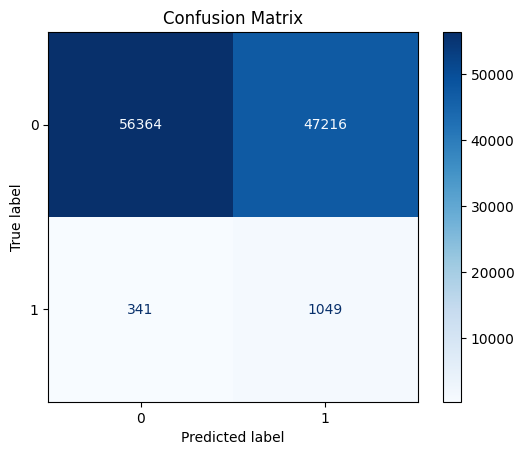

In [91]:
# logistic regression model
model = LogisticRegression(
    max_iter = 1000,
    class_weight = 'balanced',
    random_state = 42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluate_model(model, X_test, y_test, y_pred)

### Radom Forest Classifier

##### Gebalanceerd trainen

Accuracy: 0.9828331904353624
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99    103580
           1       0.33      0.28      0.30      1390

    accuracy                           0.98    104970
   macro avg       0.66      0.64      0.65    104970
weighted avg       0.98      0.98      0.98    104970



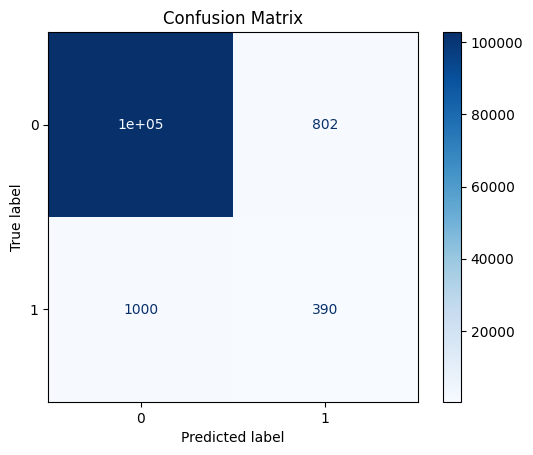

In [96]:
model = RandomForestClassifier(
    n_estimators = 100,
    class_weight = 'balanced',
    random_state = 42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluate_model(model, X_test, y_test, y_pred)

##### Ongebalanceerd trainen

Accuracy: 0.9894160236257978
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99    103580
           1       0.81      0.26      0.39      1390

    accuracy                           0.99    104970
   macro avg       0.90      0.63      0.69    104970
weighted avg       0.99      0.99      0.99    104970



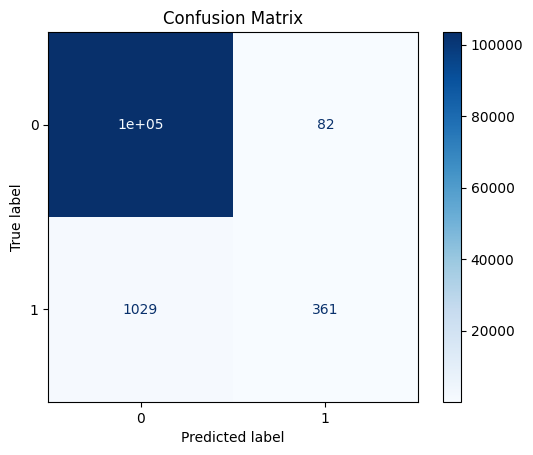

In [92]:
model = RandomForestClassifier(
    n_estimators = 100,
    class_weight = None,
    random_state = 42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluate_model(model, X_test, y_test, y_pred)

##### Evaluatie

Gebalanceerd of ongebalanceerd trainen lijkt bij een random forest classifier vrij weinig verschil te maken op 1 plek na. De false-positives zijn bijna volledig verdwenen. Het model classificeerd ongeveer 25% van de phishing emails correct dit is misschien niet heel veel, maar van deze 25% kan je er dus wel van uit gaan dat het echte phishing emails zijn met maar een kleine kans op een false positive.

### Decision Tree Classifier

#### Max Depth = 2

Accuracy: 0.4822711250833572
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.48      0.65    103580
           1       0.02      0.85      0.04      1390

    accuracy                           0.48    104970
   macro avg       0.51      0.66      0.34    104970
weighted avg       0.98      0.48      0.64    104970



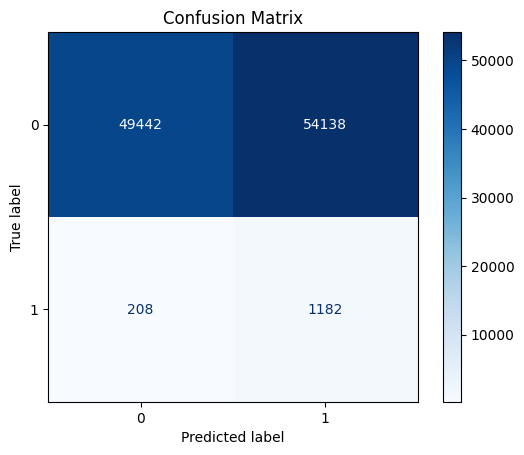

In [ ]:
model = DecisionTreeClassifier(
    class_weight = 'balanced',
    random_state = 42,
    max_depth = 2
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluate_model(model, X_test, y_test, y_pred)

#### Max Depth = 5

Accuracy: 0.6034200247689816
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.60      0.75    103580
           1       0.03      0.77      0.05      1390

    accuracy                           0.60    104970
   macro avg       0.51      0.68      0.40    104970
weighted avg       0.98      0.60      0.74    104970



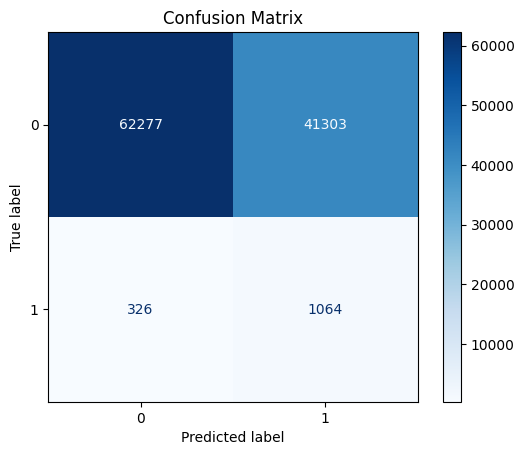

In [ ]:
model = DecisionTreeClassifier(
    class_weight = 'balanced',
    random_state = 42,
    max_depth = 2
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluate_model(model, X_test, y_test, y_pred)

#### Max Depth = 10

Accuracy: 0.8885205296751453
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.89      0.94    103580
           1       0.06      0.53      0.11      1390

    accuracy                           0.89    104970
   macro avg       0.53      0.71      0.53    104970
weighted avg       0.98      0.89      0.93    104970



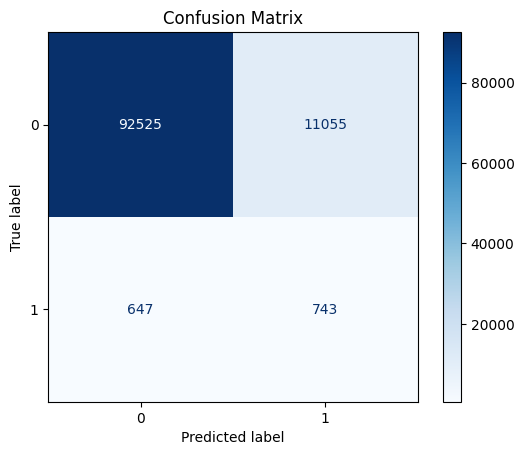

In [ ]:
model = DecisionTreeClassifier(
    class_weight = 'balanced',
    random_state = 42,
    max_depth = 10
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluate_model(model, X_test, y_test, y_pred)

#### No max depth

Accuracy: 0.9735638753929694
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99    103580
           1       0.21      0.35      0.26      1390

    accuracy                           0.97    104970
   macro avg       0.60      0.67      0.62    104970
weighted avg       0.98      0.97      0.98    104970



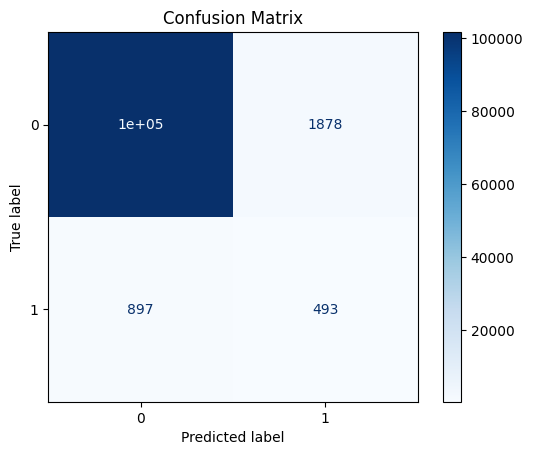

In [ ]:
model = DecisionTreeClassifier(
    class_weight = 'balanced',
    random_state = 42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluate_model(model, X_test, y_test, y_pred)

# Vergelijking van resultaten

# Reflectie